In [39]:
!pip install -U transformers
!pip install -U accelerate
!pip install -U datasets
!pip install -U bertviz
!pip install -U umap-learn


In [40]:
import pandas as pd
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import wandb
%matplotlib inline

# Read Data

In [41]:
df = pd.read_parquet("hf://datasets/dair-ai/emotion/unsplit/train-00000-of-00001.parquet")

In [42]:
mask=np.array(Image.open("/content/stormtrooper_mask.png"))

In [43]:
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


In [44]:
df.shape

(416809, 2)

In [45]:
df.isnull().sum()

,0
text,0
label,0


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416809 entries, 0 to 416808
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    416809 non-null  object
 1   label   416809 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 6.4+ MB


<ipython-input-47-196f7ff873d1>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="label",palette="gnuplot")


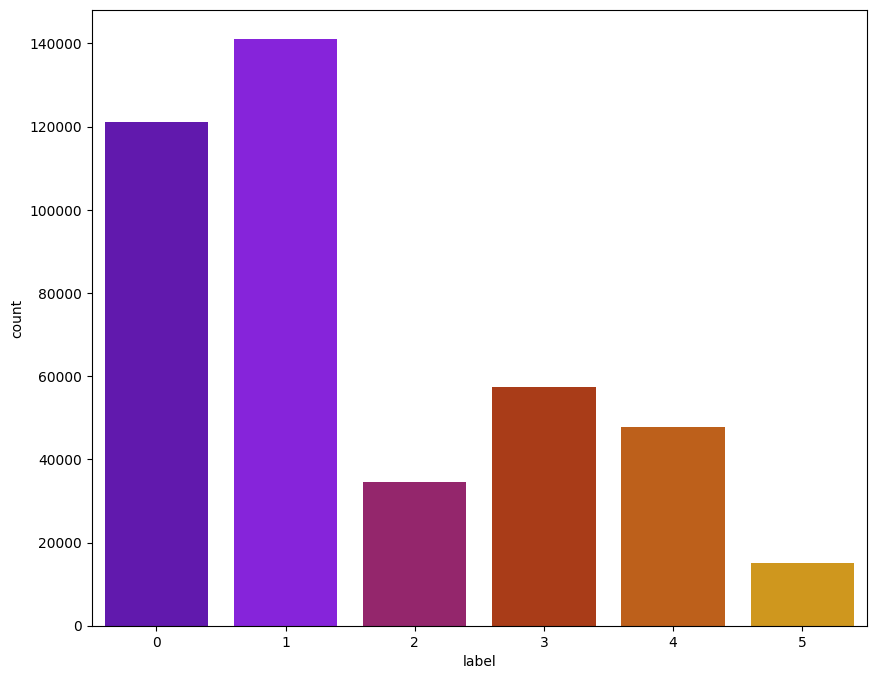

In [47]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,x="label",palette="gnuplot")
plt.show()

In [48]:
df["label"].value_counts()

,count
label,
1,141067
0,121187
3,57317
4,47712
2,34554
5,14972


# Label Mapping

In [49]:
label_mapping = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}
df["label_name"]=df["label"].map(label_mapping)

In [50]:
my_label=df["label_name"].unique()
print(my_label)

['sadness' 'joy' 'love' 'anger' 'fear' 'surprise']


<ipython-input-51-d646a58808d7>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,x="label_name",palette="nipy_spectral")


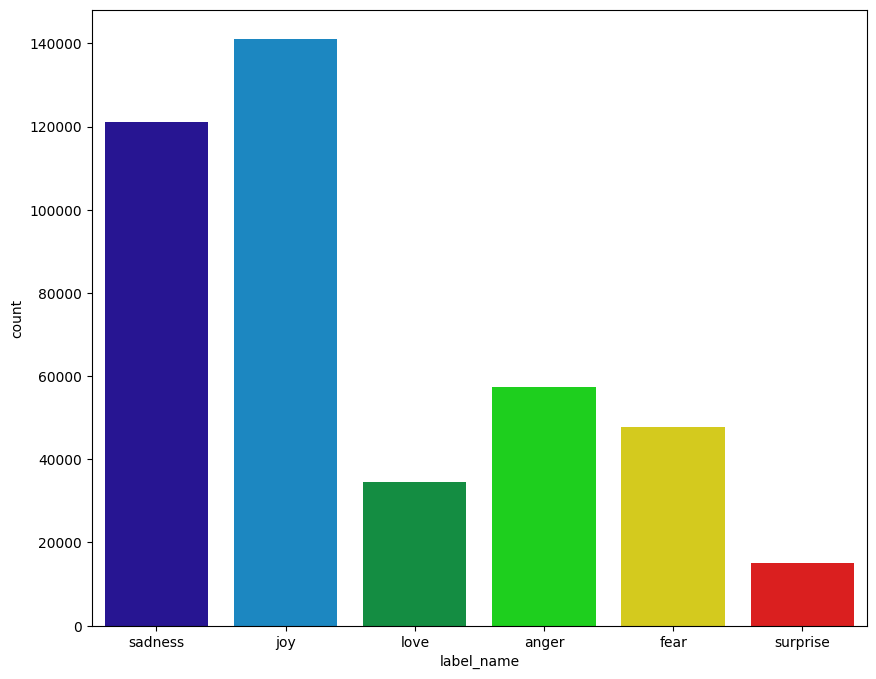

In [51]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,x="label_name",palette="nipy_spectral")
plt.show()

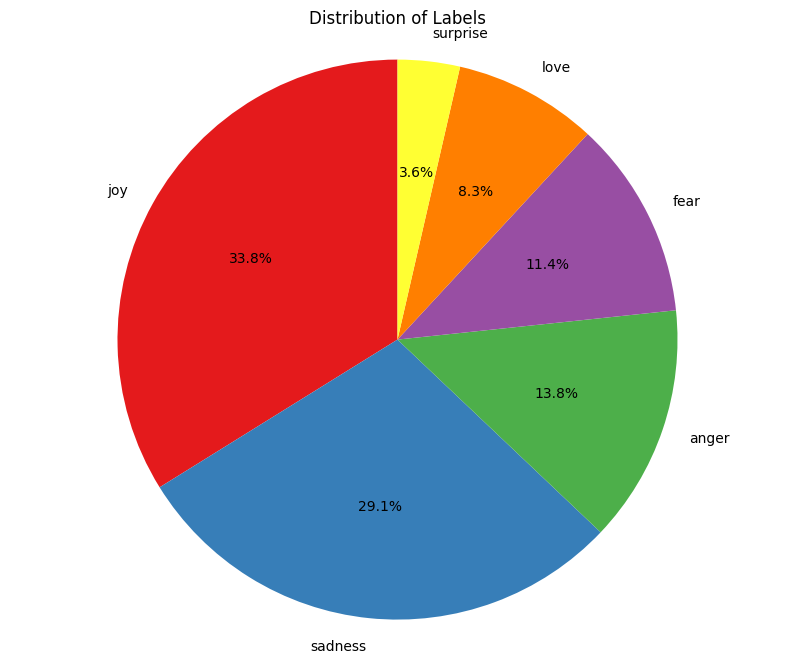

In [52]:
label_counts = df['label_name'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(label_counts,labels=label_counts.index,autopct='%1.1f%%',startangle=90,colors=plt.cm.Set1(range(len(label_counts))))
plt.title("Distribution of Labels")
plt.axis("equal")
plt.show()

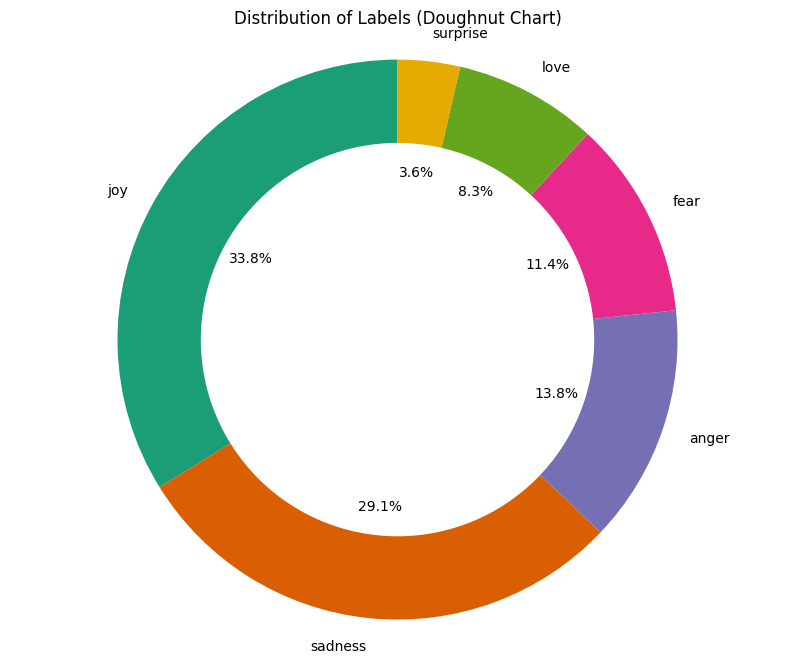

In [53]:
plt.figure(figsize=(10, 8))
plt.pie(
    label_counts,
    labels=label_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Dark2(range(len(label_counts)))
)
center_circle = plt.Circle((0, 0), 0.70, color='white')
plt.gca().add_artist(center_circle)
plt.axis("equal")
plt.title("Distribution of Labels (Doughnut Chart)")
plt.show()

In [54]:
df1=df.copy()
df1.head()

,text,label,label_name
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


# Clean Data

In [55]:
from bs4 import BeautifulSoup
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [56]:
def clean_text(text):
    if isinstance(text, str):
        text = BeautifulSoup(text, 'html.parser').get_text()
        text = re.sub(r"[^a-zA-Z]", " ", text)
        text = text.translate(str.maketrans("", "", string.punctuation))

        emoji_pattern = re.compile("["
                                   u"\U0001F600-\U0001F64F"
                                   u"\U0001F300-\U0001F5FF"
                                   u"\U0001F680-\U0001F6FF"
                                   u"\U0001F1E0-\U0001F1FF"
                                   u"\U00002702-\U000027B0"
                                   u"\U000024C2-\U0001F251"
                                   "]+", flags=re.UNICODE)
        text = emoji_pattern.sub(r'', text)

        text = re.sub(r"#.*", "", text)
        text = re.sub(r"/\*.*?\*/", "", text, flags=re.DOTALL)
        text = text.lower()

        stop_words = set(stopwords.words('english'))
        tokens = word_tokenize(text)
        tokens = [word for word in tokens if word not in stop_words]

        text = ' '.join(tokens)

        return text
    else:
        return ""

In [57]:
df1["text"]=df1["text"].apply(clean_text)

# All Data WordCloud

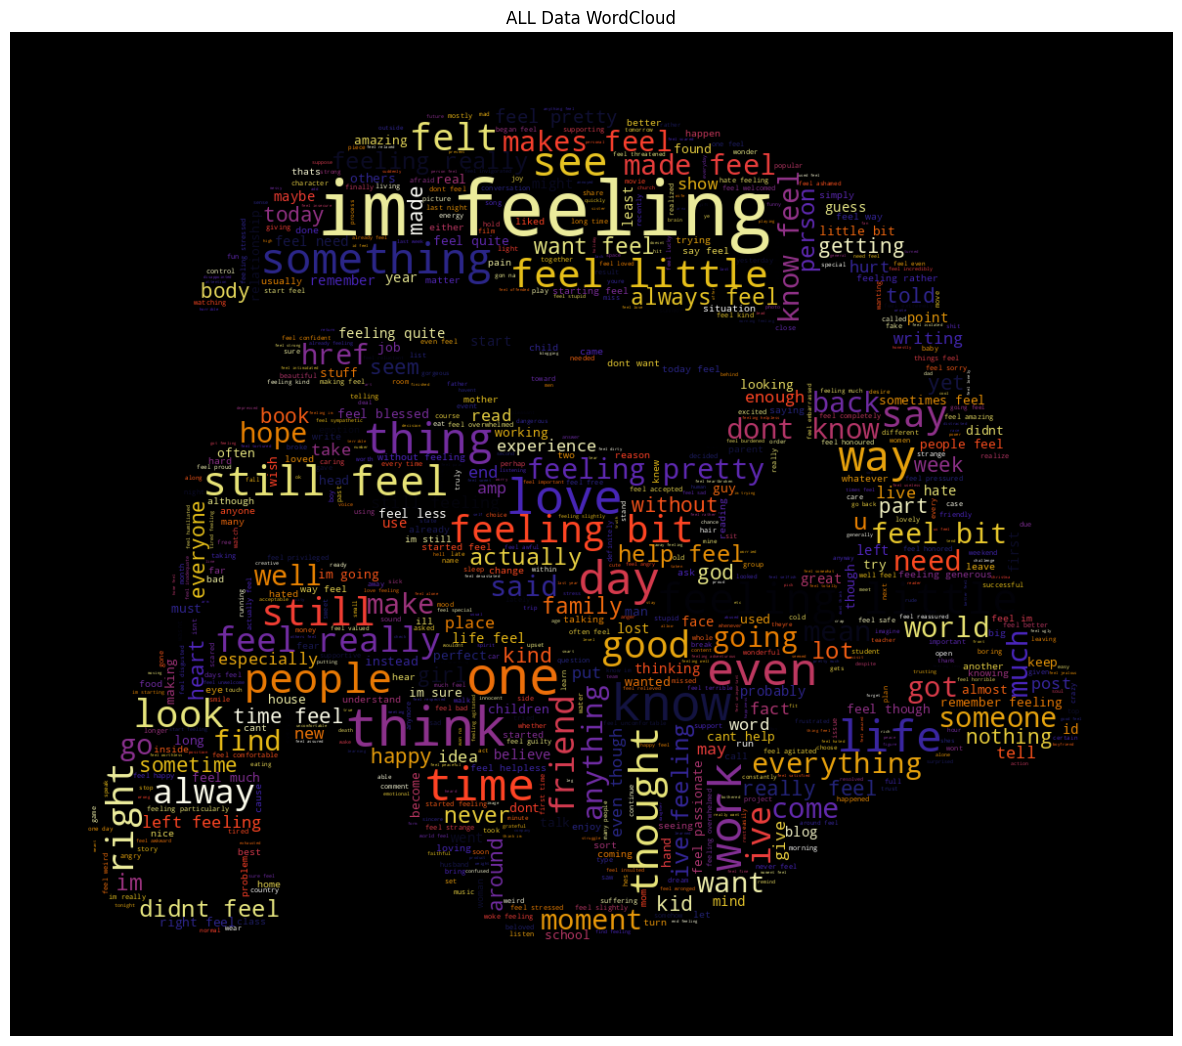

In [58]:
from wordcloud import WordCloud, STOPWORDS
plt.figure(figsize=(15,15))
all_text=" ".join(df1['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="CMRmap",mask=mask).generate(all_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("ALL Data WordCloud")
plt.show()

# Sadness Data Wordcloud

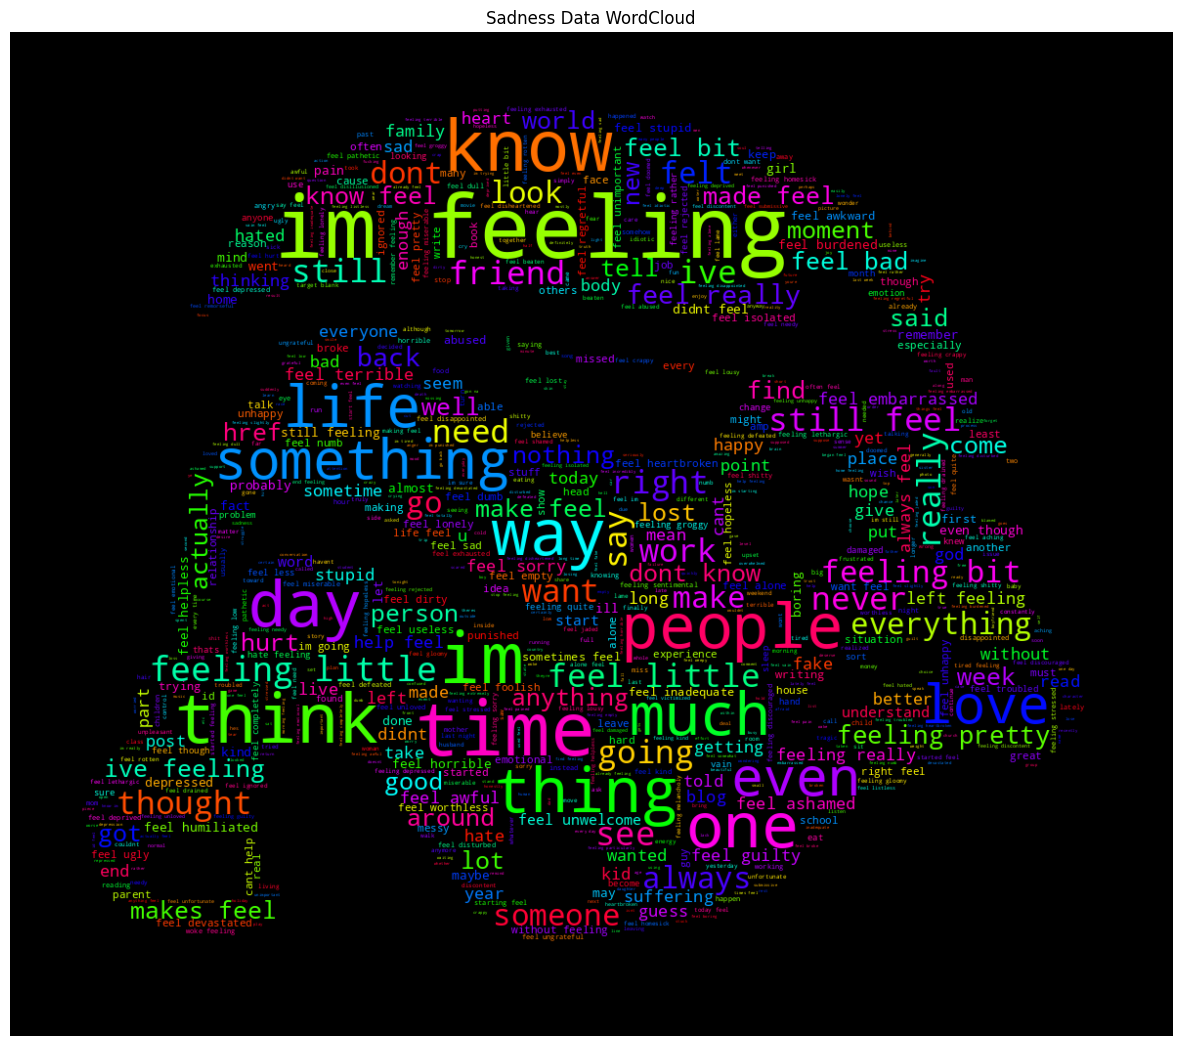

In [59]:
plt.figure(figsize=(15,15))
sadness_wordcloud=df1[df1["label"]==0]
sadness_text=" ".join(sadness_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="hsv",mask=mask).generate(sadness_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Sadness Data WordCloud")
plt.axis('off')
plt.show()

# Joy Data WordCloud

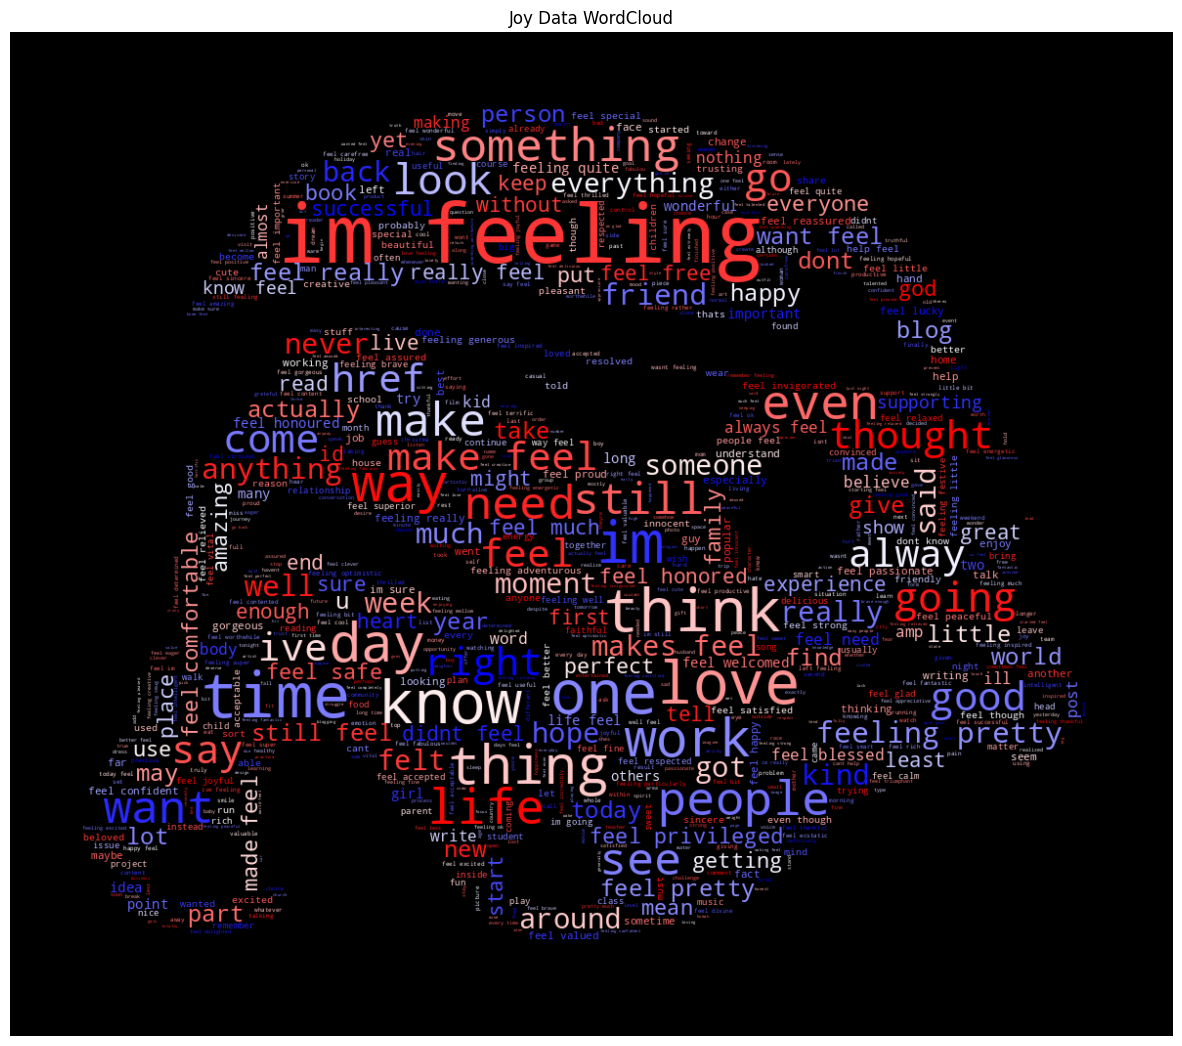

In [60]:
plt.figure(figsize=(15,15))
joy_wordcloud=df1[df1["label"]==1]
joy_text=" ".join(joy_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="bwr",mask=mask).generate(joy_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Joy Data WordCloud")
plt.axis('off')
plt.show()

# Love Data WordCloud

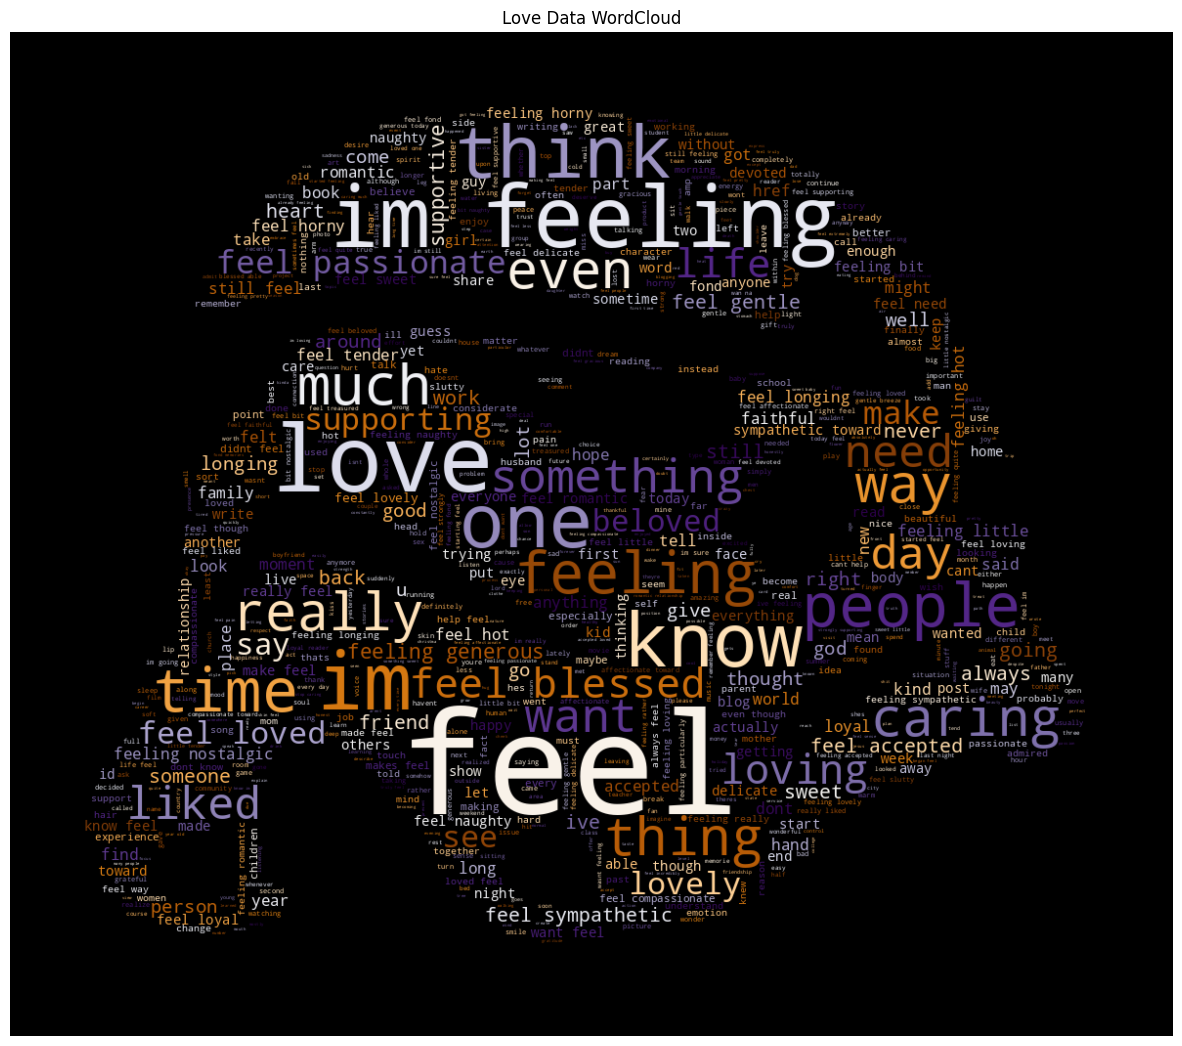

In [61]:
plt.figure(figsize=(15,15))
love_wordcloud=df1[df1["label"]==2]
love_text=" ".join(love_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="PuOr",mask=mask).generate(love_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Love Data WordCloud")
plt.axis('off')
plt.show()

# Anger Data WordCloud

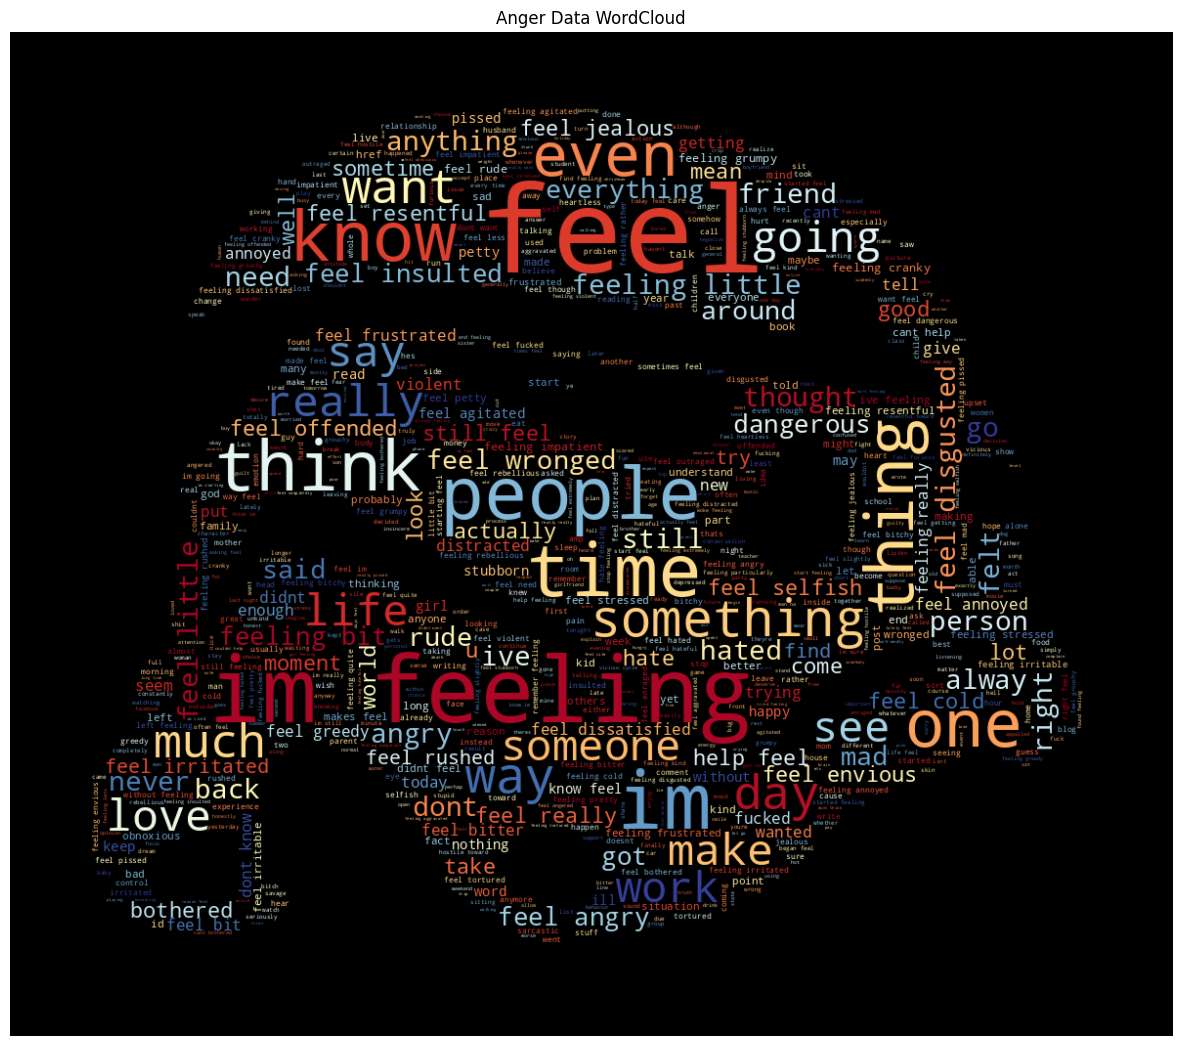

In [62]:
plt.figure(figsize=(15,15))
anger_wordcloud=df1[df1["label"]==3]
anger_text=" ".join(anger_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="RdYlBu",mask=mask).generate(anger_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Anger Data WordCloud")
plt.axis('off')
plt.show()

# fear DAta WordCloud

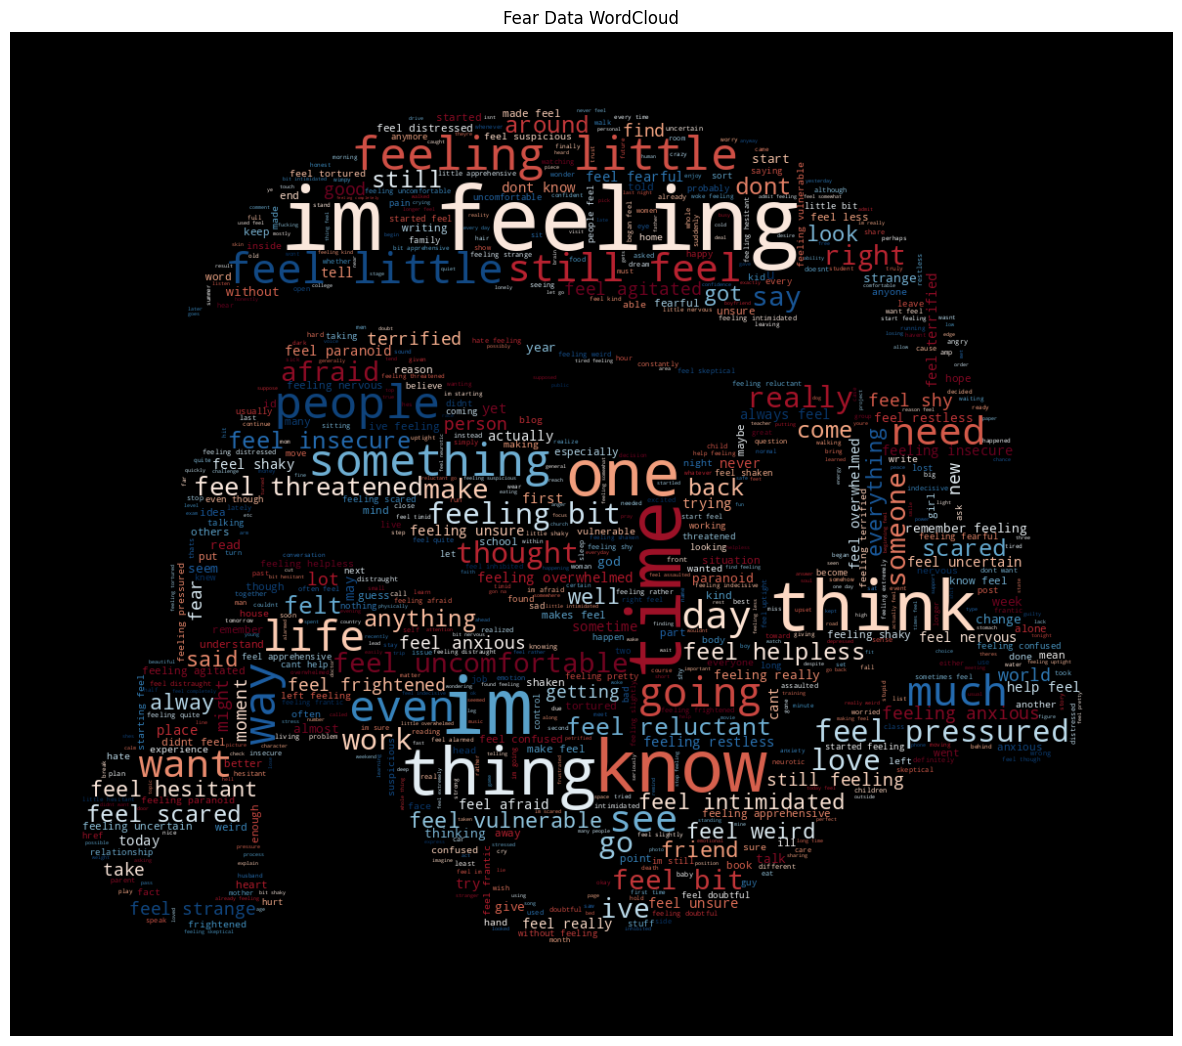

In [63]:
plt.figure(figsize=(15,15))
fear_wordcloud=df1[df1["label"]==4]
fear_text=" ".join(fear_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="RdBu",mask=mask).generate(fear_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Fear Data WordCloud")
plt.axis('off')
plt.show()

# Surprise Data WordCloud

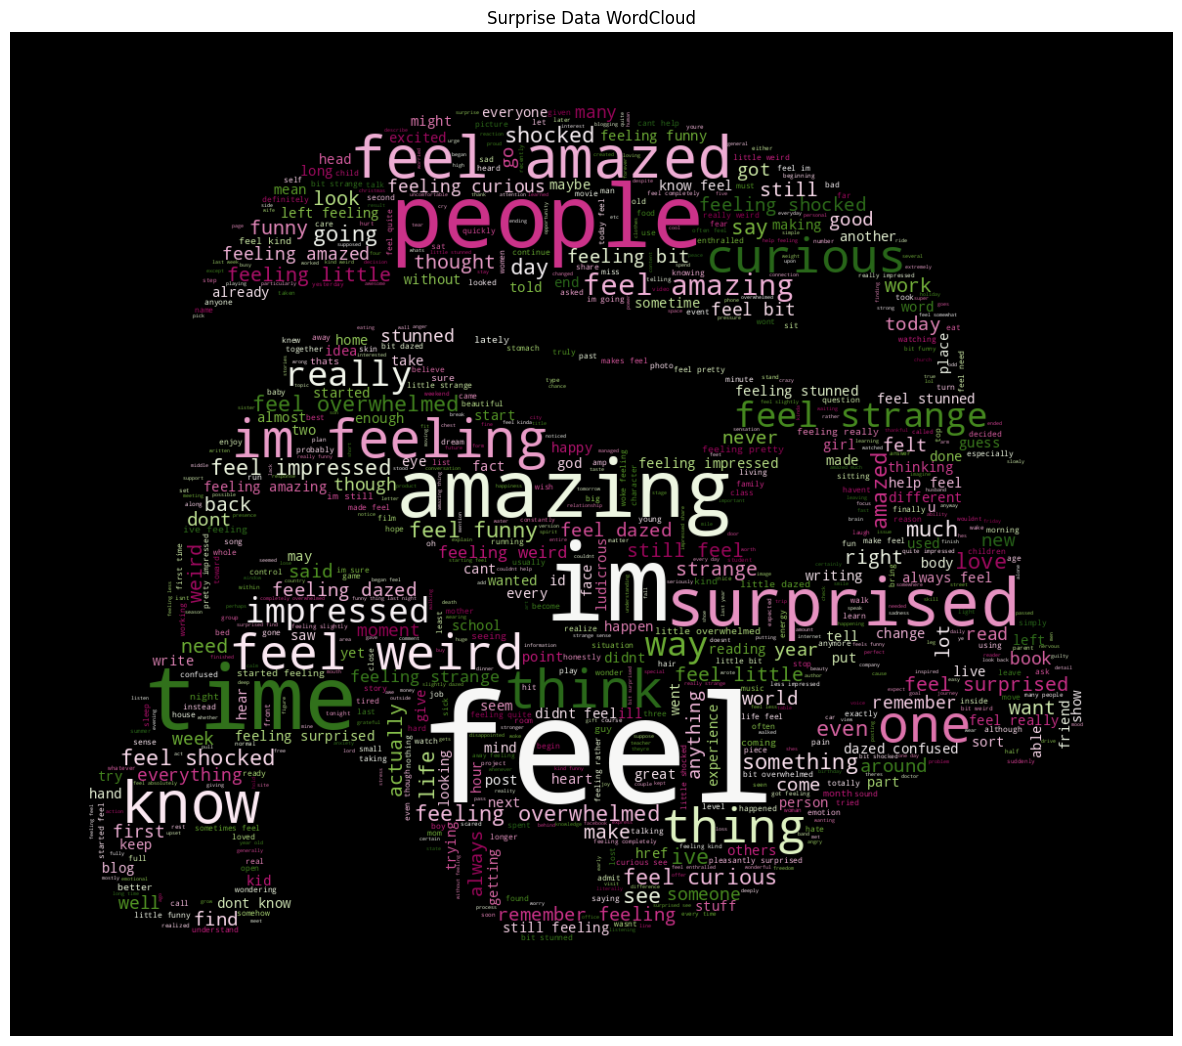

In [64]:
plt.figure(figsize=(15,15))
surprise_wordcloud=df1[df1["label"]==5]
surprise_text=" ".join(surprise_wordcloud['text'].values.tolist())
wordcloud = WordCloud(width=800, height=800,stopwords=STOPWORDS, background_color='black', max_words=800,colormap="PiYG",mask=mask).generate(surprise_text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("Surprise Data WordCloud")
plt.axis('off')
plt.show()

# 30 Most common Words From All Text

<ipython-input-65-2851577b372d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=colors)


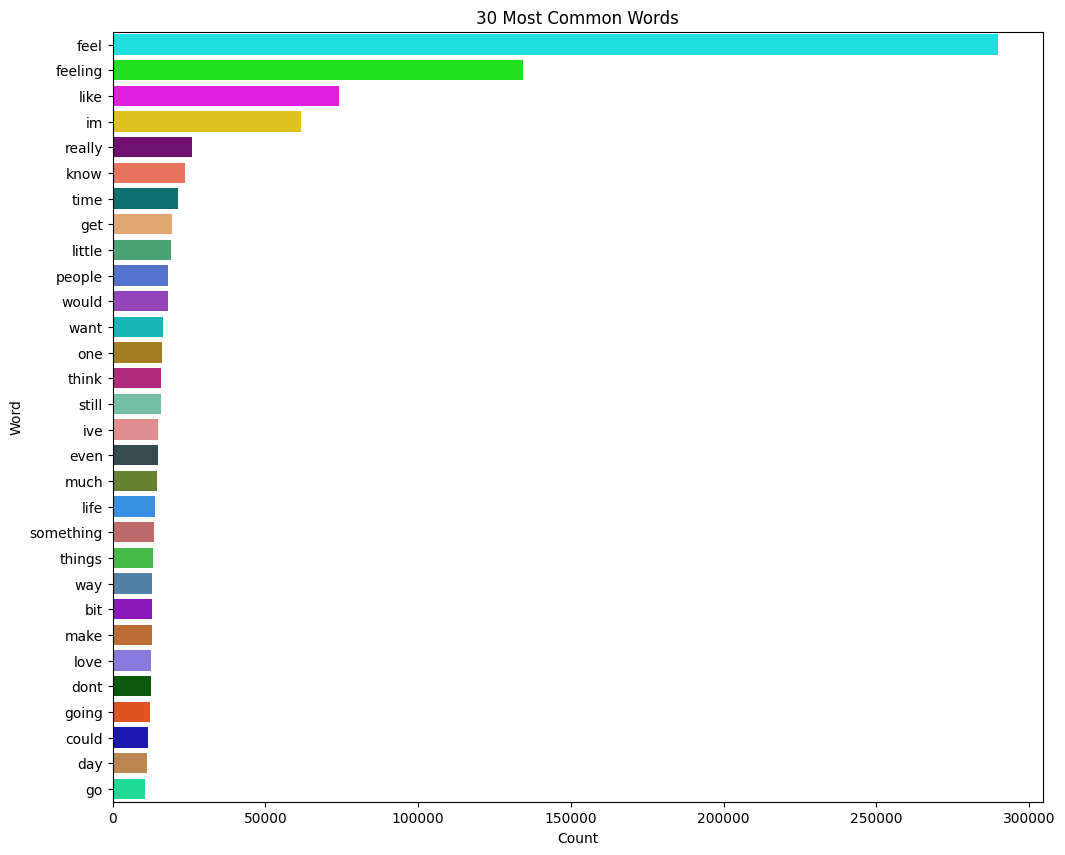

In [65]:
from itertools import chain
from collections import Counter

data_set =df1["text"].str.split()
all_words = list(chain.from_iterable(data_set))
counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

colors = ["cyan", "lime", "magenta", "gold", "purple", "tomato", "teal", "sandybrown", "mediumseagreen",
          "royalblue", "darkorchid", "darkturquoise", "darkgoldenrod", "mediumvioletred", "mediumaquamarine",
          "lightcoral", "darkslategray", "olivedrab", "dodgerblue", "indianred", "limegreen", "steelblue",
          "darkviolet", "chocolate", "mediumslateblue", "darkgreen", "orangered", "mediumblue", "peru", "mediumspringgreen"]

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=colors)
plt.title('30 Most Common Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Sadness Text

<ipython-input-66-7b5e7353223a>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Dark2", n_colors=len(df_common_words)))


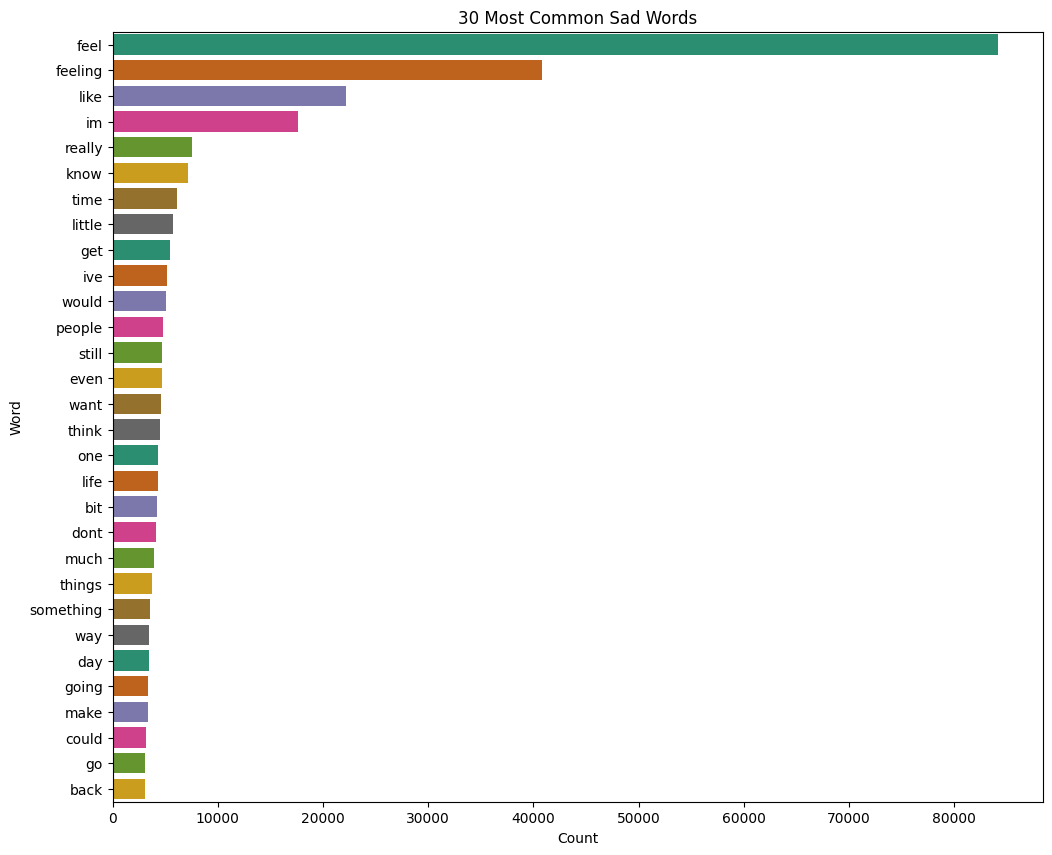

In [66]:
sadness_text = df1[df1["label"] == 0]
data_set = sadness_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Dark2", n_colors=len(df_common_words)))
plt.title('30 Most Common Sad Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Joy Text

<ipython-input-67-9a3a629fc7da>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Paired", n_colors=len(df_common_words)))


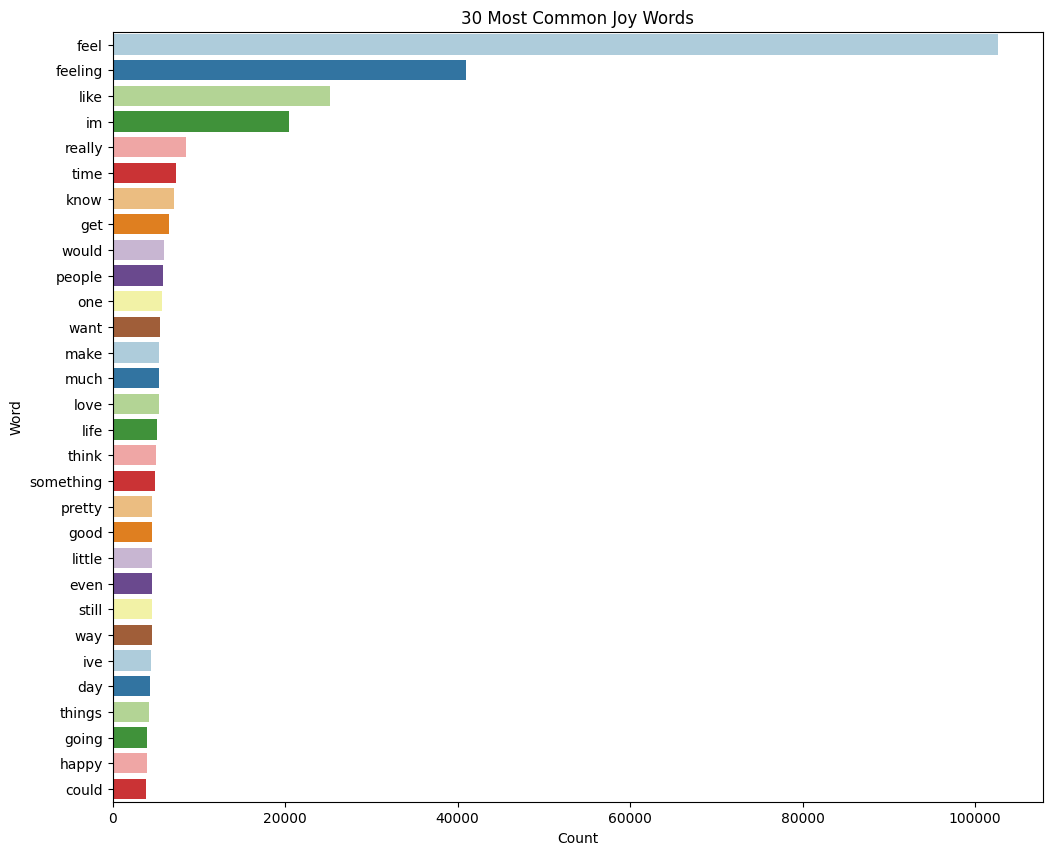

In [67]:
joy_text = df1[df1["label"] == 1]
data_set = joy_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Paired", n_colors=len(df_common_words)))
plt.title('30 Most Common Joy Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Love Text

<ipython-input-68-6cbbf6a65f59>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Accent", n_colors=len(df_common_words)))


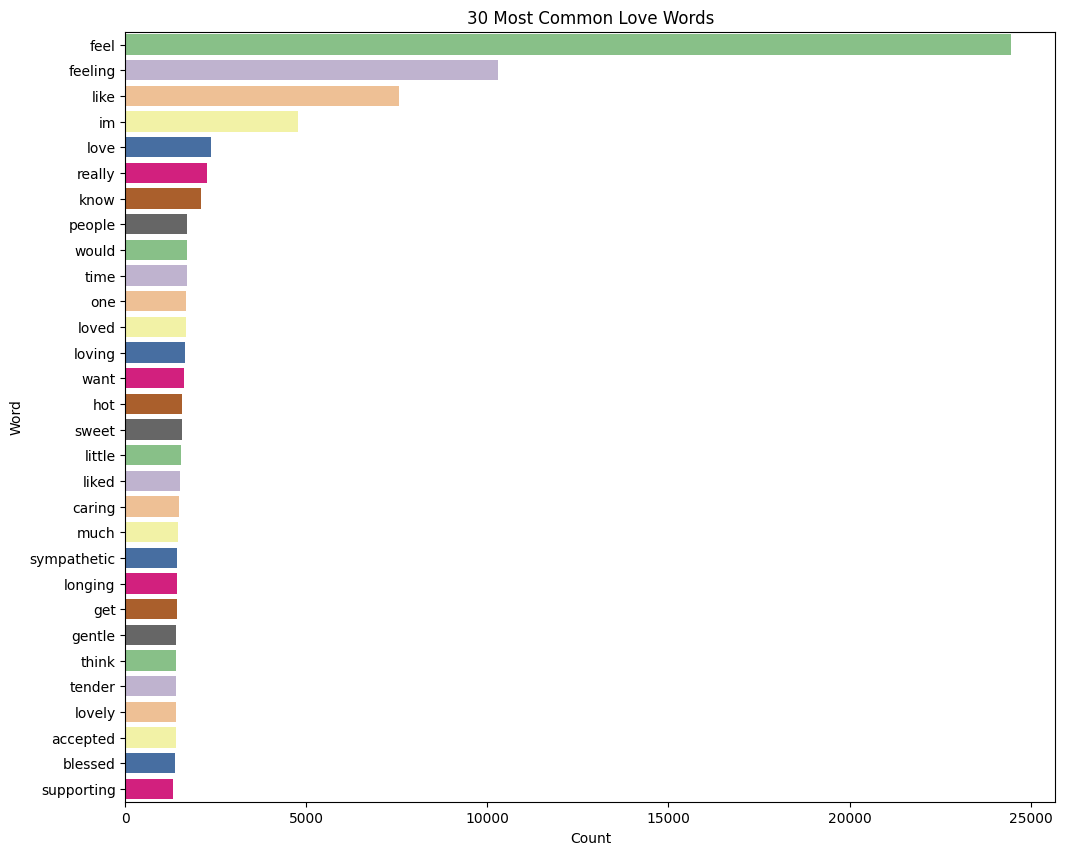

In [68]:
love_text = df1[df1["label"] == 2]
data_set = love_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Accent", n_colors=len(df_common_words)))
plt.title('30 Most Common Love Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Anger Text

<ipython-input-69-b4be4cd1dd87>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Set3", n_colors=len(df_common_words)))


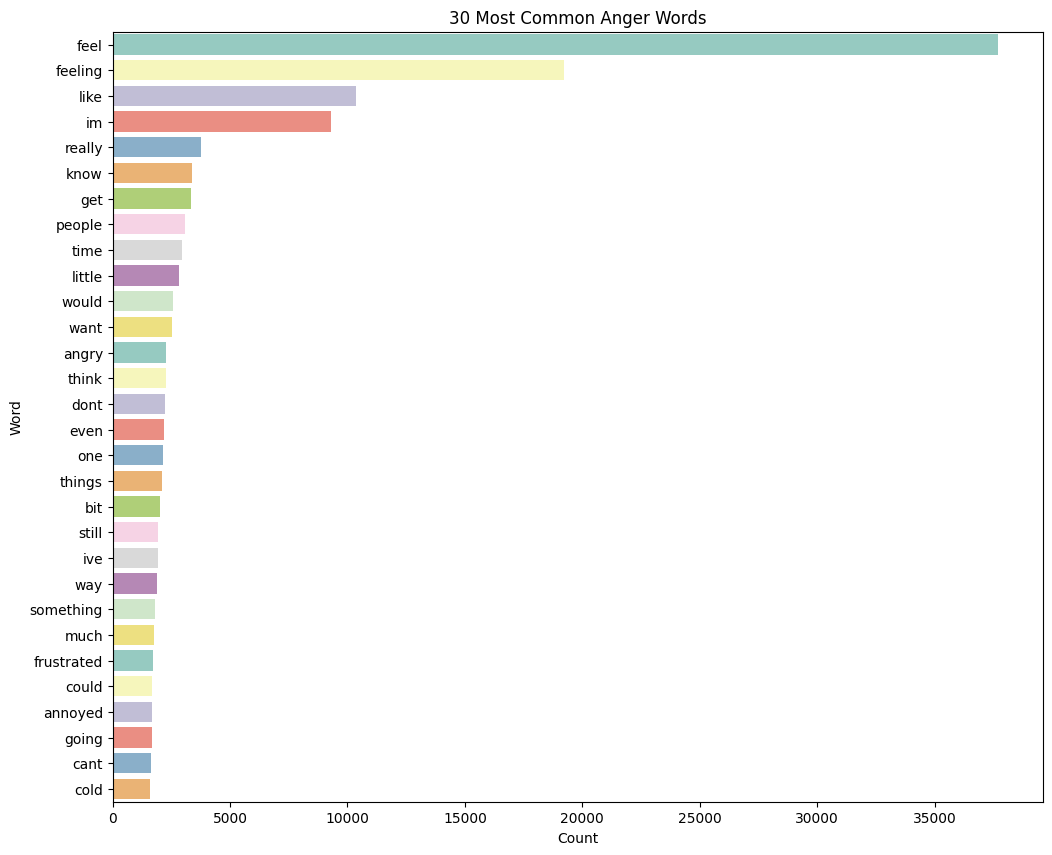

In [69]:
anger_text = df1[df1["label"] == 3]
data_set = anger_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("Set3", n_colors=len(df_common_words)))
plt.title('30 Most Common Anger Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Fear Text

<ipython-input-70-2c99112afb4b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("spring", n_colors=len(df_common_words)))


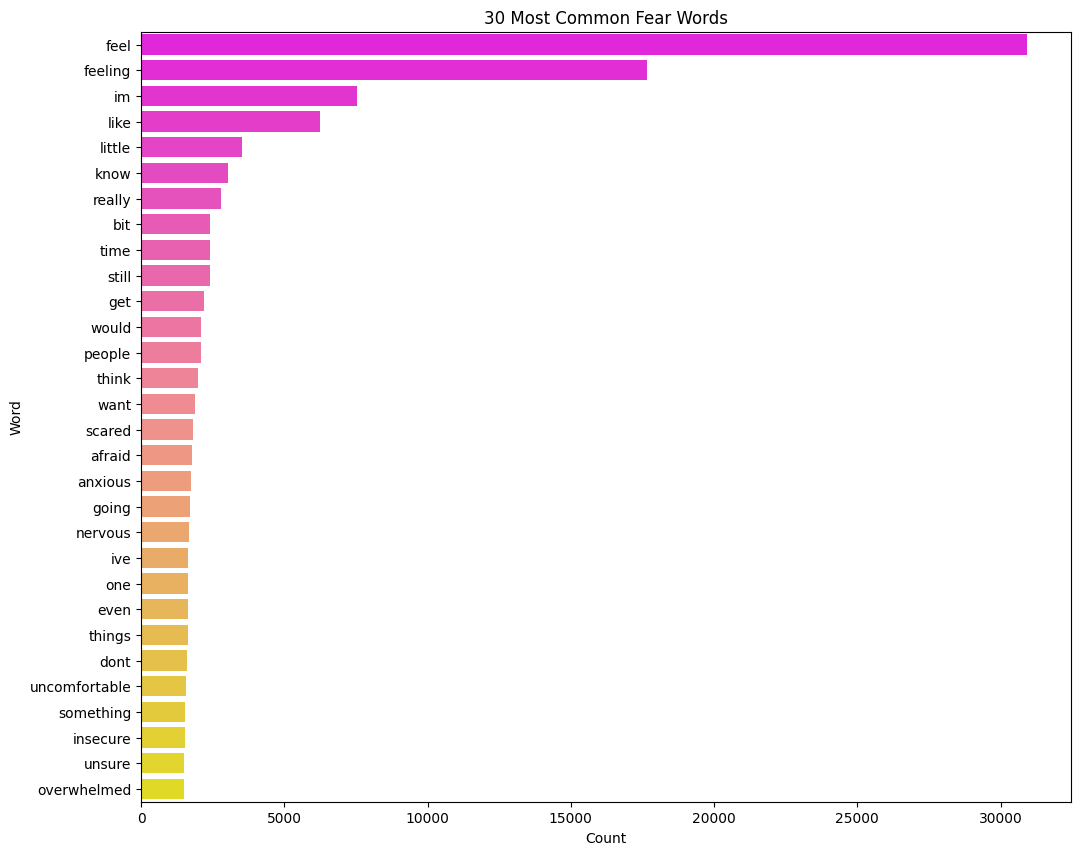

In [70]:
fear_text = df1[df1["label"] == 4]
data_set = fear_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("spring", n_colors=len(df_common_words)))
plt.title('30 Most Common Fear Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

# Most Common Words From Surprise Text

<ipython-input-71-d89c84fa7a4b>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("cool", n_colors=len(df_common_words)))


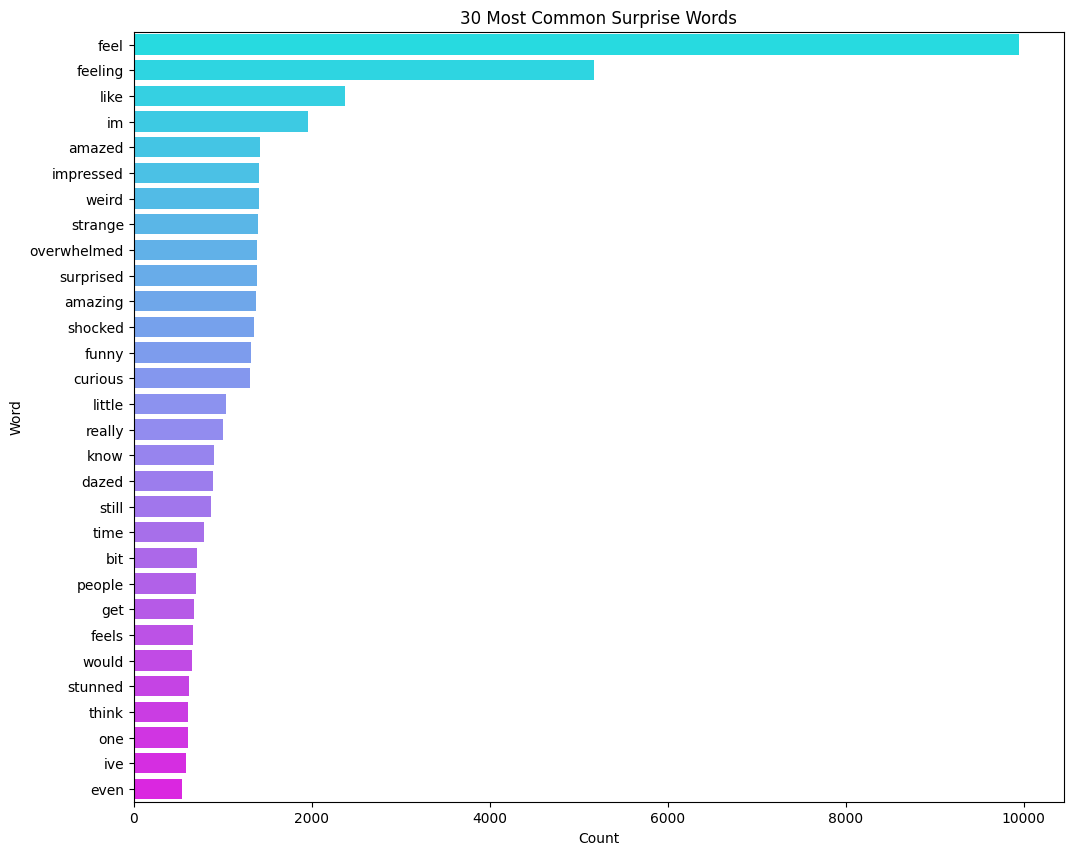

In [71]:
surprise_text = df1[df1["label"] == 5]
data_set = surprise_text["text"].str.split()
all_words = [word for sublist in data_set for word in sublist]

counter = Counter(all_words)
common_words = counter.most_common(30)
df_common_words = pd.DataFrame(common_words, columns=['Word', 'Count'])

plt.figure(figsize=(12, 10))
sns.barplot(x='Count', y='Word', data=df_common_words, palette=sns.color_palette("cool", n_colors=len(df_common_words)))
plt.title('30 Most Common Surprise Words')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

In [72]:
df.head()

,text,label,label_name
0,i feel awful about it too because it s my job ...,0,sadness
1,im alone i feel awful,0,sadness
2,ive probably mentioned this before but i reall...,1,joy
3,i was feeling a little low few days back,0,sadness
4,i beleive that i am much more sensitive to oth...,2,love


# Calculate the length of each text entry

In [73]:
df['text_length'] = df['text'].apply(len)


average_text_length = df['text_length'].mean()

print(f"Average Text Length: {average_text_length:.2f}")

Average Text Length: 97.03


In [74]:
df.drop(columns=["text_length"],axis=1,inplace=True)

# Load Distilbert Model

In [75]:
from transformers import AutoTokenizer, DistilBertModel
import torch
distilbert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = DistilBertModel.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [76]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We'll use this text to understand the tokenization process:

In [77]:
sample_text="update getting response developer would change rating stars possible guys hide behind confusing opaque terms refuse budge annoyed money lost really terrible customer experience original careful signing free trial app happen go automatically charge full years subscription refuse refund terrible customer experience app ok according tos term agreed upon creating free trial days automatic charge plan unless cancel prior renewal date cancel subscription time charged per agreement"

# Some basic operations can convert the text to tokens and tokens to unique integers (ids):

In [78]:
tokens = distilbert_tokenizer.tokenize(sample_text)
token_ids = distilbert_tokenizer.convert_tokens_to_ids(tokens)

print("================================================================================================")

print(f'Sentence: {sample_text}')
print("================================================================================================")
print(f'Tokens: {tokens}')
print("================================================================================================")
print(f'Token IDs: {token_ids}')
print("================================================================================================")

Sentence: update getting response developer would change rating stars possible guys hide behind confusing opaque terms refuse budge annoyed money lost really terrible customer experience original careful signing free trial app happen go automatically charge full years subscription refuse refund terrible customer experience app ok according tos term agreed upon creating free trial days automatic charge plan unless cancel prior renewal date cancel subscription time charged per agreement
Tokens: ['update', 'getting', 'response', 'developer', 'would', 'change', 'rating', 'stars', 'possible', 'guys', 'hide', 'behind', 'confusing', 'opaque', 'terms', 'refuse', 'budge', 'annoyed', 'money', 'lost', 'really', 'terrible', 'customer', 'experience', 'original', 'careful', 'signing', 'free', 'trial', 'app', 'happen', 'go', 'automatically', 'charge', 'full', 'years', 'subscription', 'refuse', 'ref', '##und', 'terrible', 'customer', 'experience', 'app', 'ok', 'according', 'to', '##s', 'term', 'agreed

In [79]:
encoding = distilbert_tokenizer.encode_plus(
  sample_text,
  max_length=120,
  add_special_tokens=True,
  return_token_type_ids=False,
  padding="max_length",
  return_attention_mask=True,
  return_tensors='pt',truncation=True
)

In [80]:
print(len(encoding['input_ids'][0]))
print("===================================================================================================")
print(encoding['input_ids'][0])

120
tensor([  101, 10651,  2893,  3433,  9722,  2052,  2689,  5790,  3340,  2825,
         4364,  5342,  2369, 16801, 28670,  3408, 10214, 24981, 11654,  2769,
         2439,  2428,  6659,  8013,  3325,  2434,  6176,  6608,  2489,  3979,
        10439,  4148,  2175,  8073,  3715,  2440,  2086, 15002, 10214, 25416,
         8630,  6659,  8013,  3325, 10439,  7929,  2429,  2000,  2015,  2744,
         3530,  2588,  4526,  2489,  3979,  2420,  6882,  3715,  2933,  4983,
        17542,  3188, 14524,  3058, 17542, 15002,  2051,  5338,  2566,  3820,
          102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0])


# The attention mask has the same length:

In [81]:
print(len(encoding['attention_mask'][0]))
print("===================================================================================================")
print(encoding['attention_mask'][0])

120
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


# We can inverse the tokenization to have a look at the special tokens:

In [82]:
distilbert_tokenizer.convert_ids_to_tokens(encoding['input_ids'][0])

['[CLS]',
 'update',
 'getting',
 'response',
 'developer',
 'would',
 'change',
 'rating',
 'stars',
 'possible',
 'guys',
 'hide',
 'behind',
 'confusing',
 'opaque',
 'terms',
 'refuse',
 'budge',
 'annoyed',
 'money',
 'lost',
 'really',
 'terrible',
 'customer',
 'experience',
 'original',
 'careful',
 'signing',
 'free',
 'trial',
 'app',
 'happen',
 'go',
 'automatically',
 'charge',
 'full',
 'years',
 'subscription',
 'refuse',
 'ref',
 '##und',
 'terrible',
 'customer',
 'experience',
 'app',
 'ok',
 'according',
 'to',
 '##s',
 'term',
 'agreed',
 'upon',
 'creating',
 'free',
 'trial',
 'days',
 'automatic',
 'charge',
 'plan',
 'unless',
 'cancel',
 'prior',
 'renewal',
 'date',
 'cancel',
 'subscription',
 'time',
 'charged',
 'per',
 'agreement',
 '[SEP]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]',
 '[PAD]'

# Choosing Sequence Length

In [83]:
token_lens = []

for txt in df.text:
  tokens = distilbert_tokenizer.encode(txt, max_length=512)
  token_lens.append(len(tokens))

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


# plot the distribution using boxplot

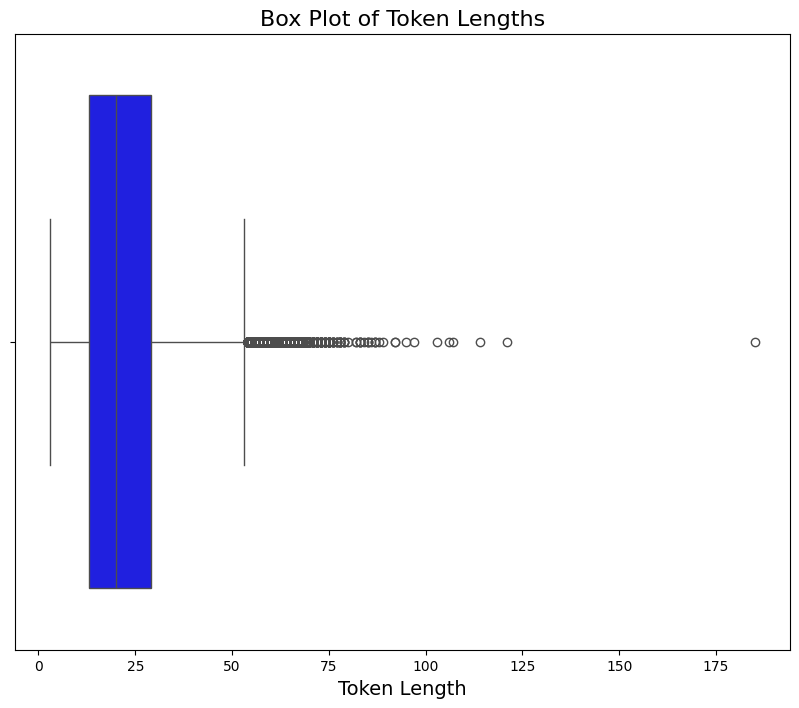

In [84]:
plt.figure(figsize=(10, 8))
sns.boxplot(x=token_lens, color='blue')

plt.title('Box Plot of Token Lengths', fontsize=16)
plt.xlabel('Token Length', fontsize=14)
plt.show()

# plot the distribution using histplot

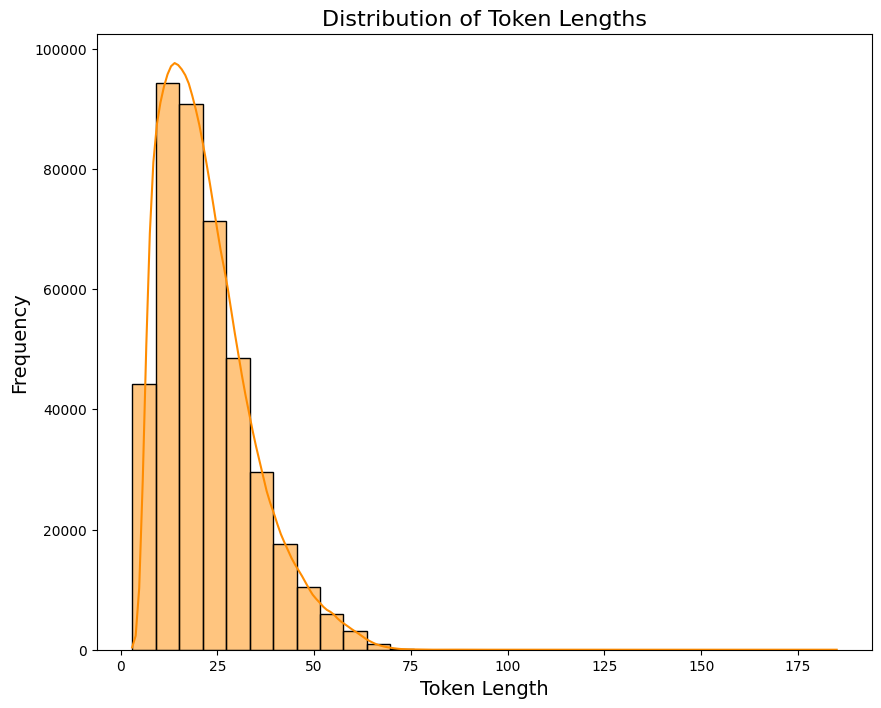

In [85]:
plt.figure(figsize=(10, 8))
sns.histplot(token_lens, bins=30, kde=True, color='darkorange')
plt.title('Distribution of Token Lengths', fontsize=16)
plt.xlabel('Token Length', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

# Calculate min, max, and average

In [86]:
import statistics


min_length = min(token_lens)
max_length = max(token_lens)
avg_length = statistics.mean(token_lens)

print("==============================================================================")
print(f"Minimum Token Length: {min_length}")
print("==============================================================================")
print(f"Maximum Token Length: {max_length}")
print("==============================================================================")
print(f"Average Token Length: {avg_length:.2f}")
print("==============================================================================")

Minimum Token Length: 3
Maximum Token Length: 185
Average Token Length: 22.31


In [87]:
distilbert_tokenizer.vocab_size, distilbert_tokenizer.model_max_length

(30522, 512)

In [88]:
df.drop(columns=["label_name"],axis=1,inplace=True)

In [89]:
df.head()

,text,label
0,i feel awful about it too because it s my job ...,0
1,im alone i feel awful,0
2,ive probably mentioned this before but i reall...,1
3,i was feeling a little low few days back,0
4,i beleive that i am much more sensitive to oth...,2


# Split Data

In [90]:
from sklearn.model_selection import train_test_split
df_train, df_remaining = train_test_split(df, test_size=0.2, random_state=42)
df_val, df_test = train_test_split(df_remaining, test_size=0.5, random_state=42)

# Create Tokenize Function

In [91]:
def tokenize(batch):
    # Tokenize the input text
    encodings = distilbert_tokenizer(
        batch['text'].tolist(),
        padding=True,             # Pads to the longest sequence in the batch or to max_length
        truncation=True,          # Truncates sequences longer than max_length
        max_length=120,           # Set a specific maximum length
        return_tensors="pt",      # Return PyTorch tensors (use "tf" for TensorFlow)
        return_attention_mask=True,  # Add attention mask
        add_special_tokens=True   # Add special tokens like [CLS] and [SEP]
    )

    return encodings

In [92]:
train_encoded = tokenize(df_train)
val_encoded = tokenize(df_val)
test_encoded = tokenize(df_test)

# Convert Data to a Dataset Format

In [93]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx]).clone().detach()
        return item


# Prepare labels

In [94]:

train_labels = df_train["label"].tolist()
val_labels = df_val["label"].tolist()
test_labels = df_test["label"].tolist()


# Create Dataset objects

In [95]:

train_dataset = EmotionDataset(train_encoded, train_labels)
val_dataset = EmotionDataset(val_encoded, val_labels)
test_dataset = EmotionDataset(test_encoded, test_labels)

In [96]:
with torch.no_grad():
  outputs = distilbert_model(**encoding)

last_hidden_states = outputs.last_hidden_state
last_hidden_states.shape

torch.Size([1, 120, 768])

# Fine-Tuning Transformers

```
The AutoModelForSequenceClassification model adds a classification head on top of a pretrained DistilBERT model, making it suitable for classification tasks. Unlike AutoModel, which only provides base model outputs, AutoModelForSequenceClassification directly supports training for classification. Simply use this model for fine-tuning on your dataset.
```

In [97]:
from transformers import AutoTokenizer, DistilBertForSequenceClassification

num_labels = len(my_label)
seq_model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=num_labels).to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Calculate Metrics

In [98]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  f1 = f1_score(labels, preds, average='weighted')
  acc = accuracy_score(labels, preds)
  return {"accuracy": acc, "f1": f1}

In [99]:
from transformers import TrainingArguments
batch_size = 32


training_args = TrainingArguments(output_dir = './results',
                                 run_name="distilbert_finetune",
                                 num_train_epochs=2,
                                 learning_rate = 2e-5,
                                 per_device_train_batch_size= batch_size,
                                 per_device_eval_batch_size = batch_size,
                                 weight_decay=0.01,
                                 eval_strategy = 'epoch',save_total_limit=2, gradient_accumulation_steps=4,
                                 disable_tqdm=False)

In [100]:
from transformers import Trainer

trainer = Trainer(model=seq_model, args=training_args,
                  compute_metrics=compute_metrics,
                  train_dataset=train_dataset,
                  eval_dataset=val_dataset,
                  tokenizer=distilbert_tokenizer)

<ipython-input-100-416492223a91>:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(model=seq_model, args=training_args,


In [101]:
import wandb

wandb.login(key="97c0d73ce3f332743f73aed9bfd6ffb011ebafb4")



wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: jarif. Use `wandb login --relogin` to force relogin
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

# Train Model

In [102]:

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.351500,0.086833,0.939997,0.940916


TrainOutput(global_step=5210, training_loss=0.5093851481197892, metrics={'train_runtime': 6559.6627, 'train_samples_per_second': 101.666, 'train_steps_per_second': 0.794, 'total_flos': 2.070237440179152e+16, 'train_loss': 0.5093851481197892, 'epoch': 1.9995201995969678})

In [103]:
preds_outputs = trainer.predict(test_dataset)
preds_outputs.metrics

{'test_loss': 0.0899602621793747,
 'test_accuracy': 0.93822125188935,
 'test_f1': 0.9392007803555056,
 'test_runtime': 125.9755,
 'test_samples_per_second': 330.866,
 'test_steps_per_second': 10.343}

In [104]:
y_preds = np.argmax(preds_outputs.predictions, axis=1)
y_true = test_labels
class_name=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

# Classification Report

In [105]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    log_loss,
    balanced_accuracy_score,
    hinge_loss,
    matthews_corrcoef,
    brier_score_loss
)

print(classification_report(y_true, y_preds,target_names=class_name))

              precision    recall  f1-score   support

     sadness       0.98      0.97      0.98     12197
         joy       0.98      0.93      0.95     14263
        love       0.79      0.93      0.85      3413
       anger       0.96      0.92      0.94      5681
        fear       0.87      0.94      0.90      4601
    surprise       0.81      0.82      0.82      1526

    accuracy                           0.94     41681
   macro avg       0.90      0.92      0.91     41681
weighted avg       0.94      0.94      0.94     41681



# Confusion Matrix

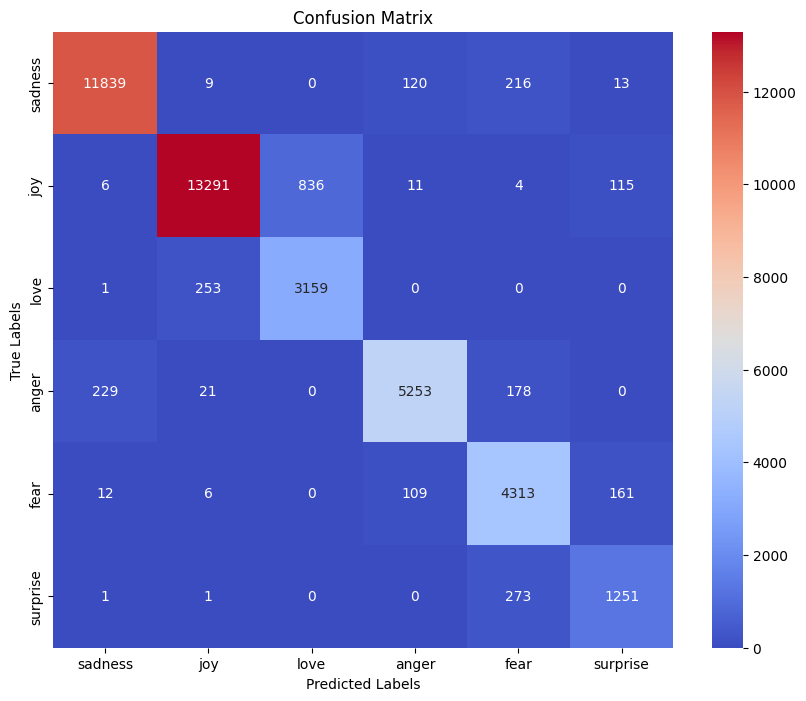

In [106]:
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_name, yticklabels=class_name)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Roc Curve

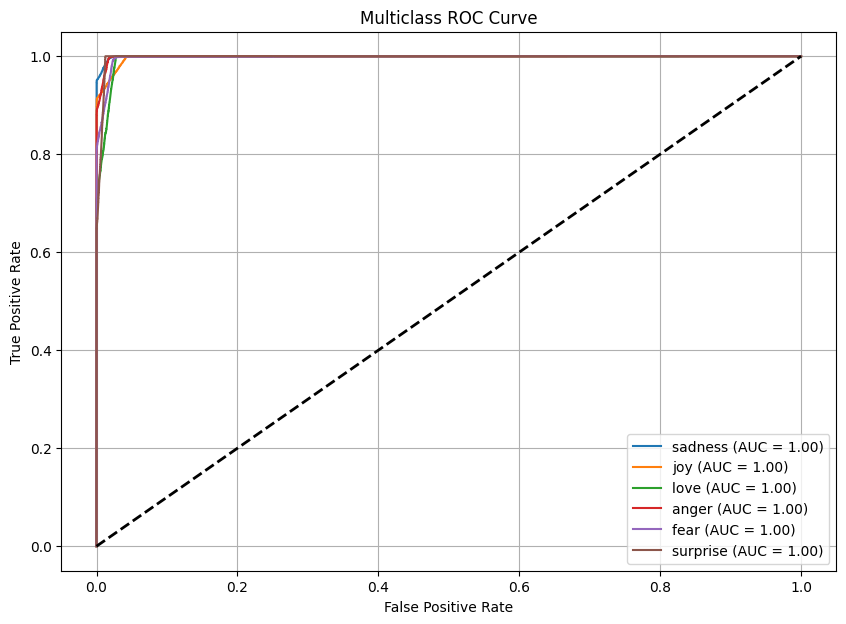

In [107]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize


y_true = np.array(y_true)
y_preds = np.array(y_preds)
class_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
n_classes = len(class_names)

y_true_binarized = label_binarize(y_true, classes=range(n_classes))
y_score = preds_outputs.predictions

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_binarized[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.title("Multiclass ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid()
plt.show()


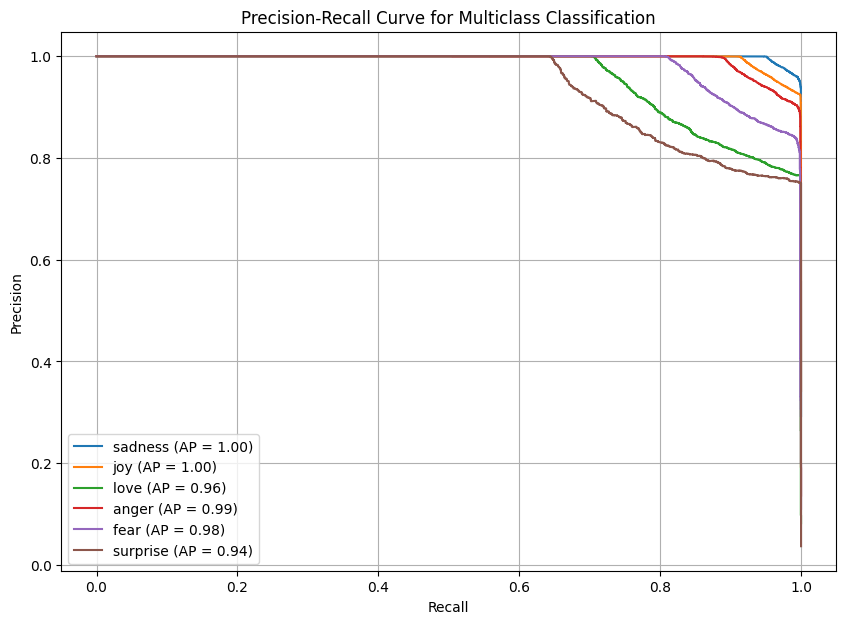

In [108]:
from sklearn.metrics import precision_recall_curve, average_precision_score
precision = {}
recall = {}
average_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_binarized[:, i], y_score[:, i])
    average_precision[i] = average_precision_score(y_true_binarized[:, i], y_score[:, i])

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(class_names):
    plt.plot(recall[i], precision[i], label=f"{class_name} (AP = {average_precision[i]:.2f})")

plt.title("Precision-Recall Curve for Multiclass Classification")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="lower left")
plt.grid()
plt.show()

# Roc Auc Score

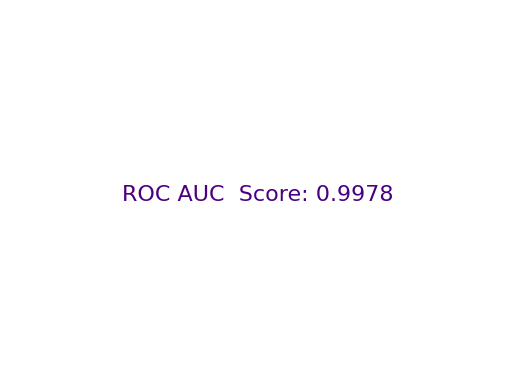

In [109]:
roc_auc = roc_auc_score(y_true_binarized, y_score,multi_class="ovr")
plt.plot([])
plt.text(0,0, f'ROC AUC  Score: {roc_auc:.4f}', fontsize=16, ha='center', va='center',color="indigo")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

#  Log Loss

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:3001: UserWarning: The y_pred values do not sum to one. Make sure to pass probabilities.
  warnings.warn(


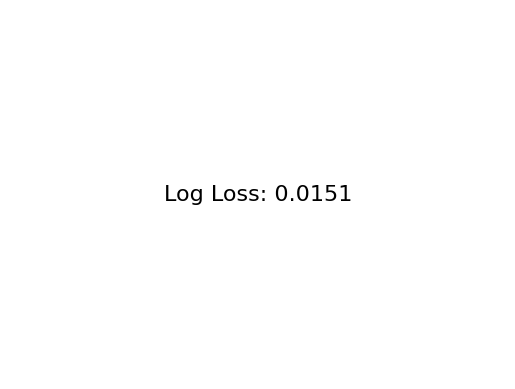

In [110]:
logarithm_loss=log_loss(y_true_binarized,y_score)
plt.plot([])
plt.text(0,0, f'Log Loss: {logarithm_loss:.4f}', fontsize=16, ha='center', va='center',color="black")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

# Cohen Kappa Score

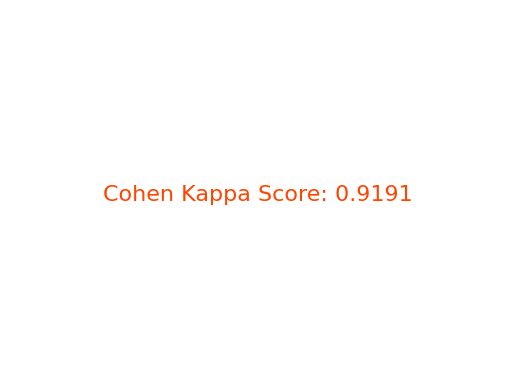

In [111]:
from sklearn.metrics import cohen_kappa_score,matthews_corrcoef
kappa = cohen_kappa_score(y_true,y_preds)
plt.plot([])
plt.text(0,0, f'Cohen Kappa Score: {kappa:.4f}', fontsize=16, ha='center', va='center',color="orangered")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()

# Matthews Correlation Coefficient

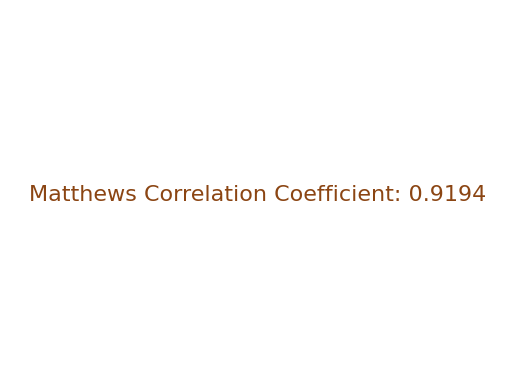

In [112]:
mcc = matthews_corrcoef(y_true,y_preds)

# Create a plot and display the MCC value as text
plt.plot([])
plt.text(0,0, f'Matthews Correlation Coefficient: {mcc:.4f}', fontsize=16, ha='center', va='center',color="saddlebrown")
plt.axis('off')

# Set the x-axis limits
plt.xlim(-1, 1)
plt.ylim(-1,1)

plt.show()


# Custom Data Prediction

In [113]:
text = "I am feeling very anxious about the upcoming event. The uncertainty is overwhelming, and I can't shake off this feeling of fear and worry."
encoded_input = distilbert_tokenizer(text, return_tensors="pt").to(device)
encoded_input = distilbert_tokenizer(text, return_tensors="pt").to(device)
with torch.no_grad():
    logits = seq_model(**encoded_input).logits
class_labels = ["sadness", "joy", "love", "anger", "fear", "surprise"]
predicted_class = torch.argmax(logits, dim=1).item()
predicted_label = class_labels[predicted_class]
result = {"class_id": predicted_class, "class_label": predicted_label}
print(result)


{'class_id': 4, 'class_label': 'fear'}
